<Figure size 640x480 with 0 Axes>

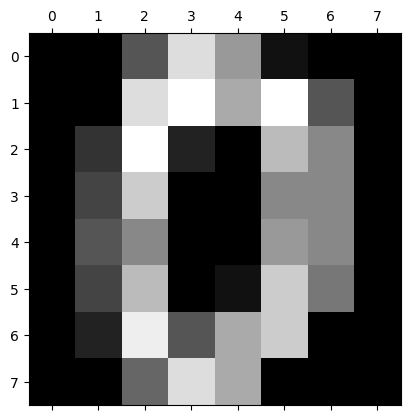

In [2]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

digits = load_digits()

plt.gray()
plt.matshow(digits.images[0])
plt.show()

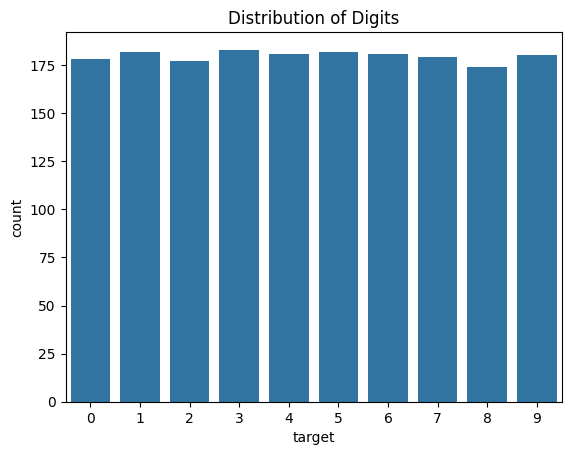

In [3]:
#EDA

import pandas as pd
import seaborn as sns 

df = pd.DataFrame(digits.target , columns = ['target']) 
sns.countplot(x = 'target' , data = df)
plt.title("Distribution of Digits")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

n_samples = len(digits.images)
data = digits.images.reshape((n_samples,-1))

X_train, X_test ,y_train , y_test = train_test_split(data , digits.target, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report , confusion_matrix

clf = SVC(gamma=0.001)
clf.fit(X_train,y_train)

predicted = clf.predict(X_test)

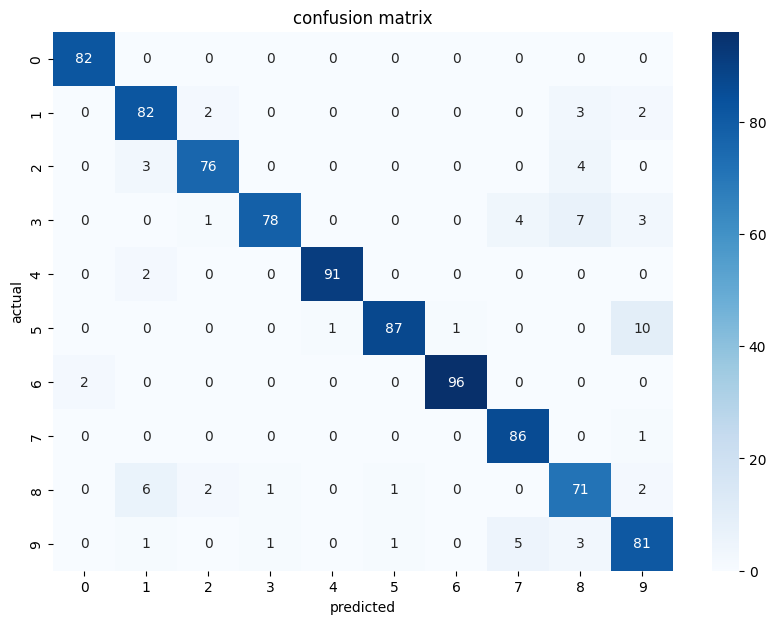

In [7]:
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test , predicted), annot=True , fmt='d' , cmap='Blues')
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix")
plt.show()

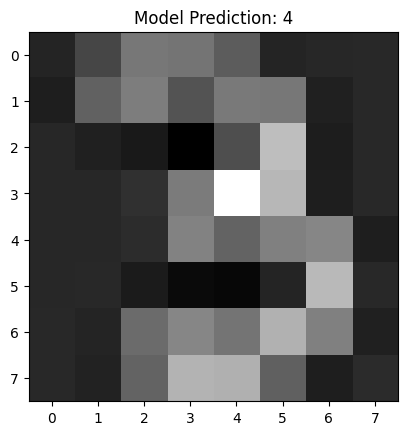

In [ ]:
from PIL import Image, ImageOps
import numpy as np
image_path = '../Data/testimg.jpg'


def predict_my_image(image_path):
    # show the original test image before processing
    orig = Image.open(image_path)
    plt.imshow(orig)
    plt.axis('off')
    plt.title('Original Test Image')
    plt.show()
    
    # 1. Open image and convert to Grayscale
    img = orig.convert('L')
    
    # 2. Resize to 8x8 pixels (The shape the model expects)
    img = img.resize((8, 8), Image.Resampling.LANCZOS)
    
    # 3. Invert Colors (Model expects white ink on black background)
    img = ImageOps.invert(img)
    
    # 4. Normalize pixel values (Scale 0-255 down to 0-16)
    img_array = np.array(img)
    img_array = (img_array / 255.0) * 16.0
    
    # 5. Flatten and Predict
    flattened_img = img_array.reshape(1, -1)
    
    # Apply the same scaling you used for training
    scaled_img = scaler.transform(flattened_img) 
    
    prediction = clf.predict(scaled_img)
    
    # Show the "pixelated" version the model sees
    plt.imshow(img_array, cmap='gray')
    plt.title(f"Model Prediction: {prediction[0]}")
    plt.show()

# To use it:
predict_my_image(image_path)